Generating 110001 total points with RK5 solver (Chua's System)...
  ... generated 10000/110001 points
  ... generated 20000/110001 points
  ... generated 30000/110001 points
  ... generated 40000/110001 points
  ... generated 50000/110001 points
  ... generated 60000/110001 points
  ... generated 70000/110001 points
  ... generated 80000/110001 points
  ... generated 90000/110001 points
  ... generated 100000/110001 points
  ... generated 110000/110001 points
Generation complete.
Final dataset shape (inputs): (100000, 3)
Final dataset shape (targets): (100000, 3)
Input (u_data) and Target (d_data) datasets saved to .npy files.
Plotting attractor (x vs y) to verify...


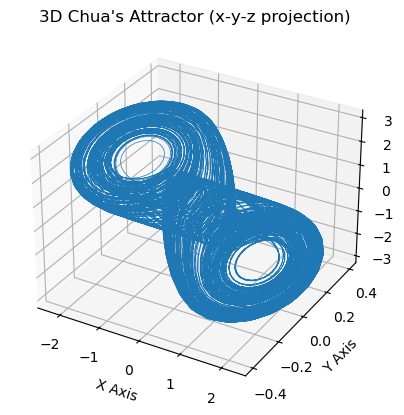

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def chua_system(state, alpha, beta, m0, m1):
    """
    Defines the differential equations for the 3D Chua's Chaotic System.
    """
    x, y, z = state
    
    # h(x) is the piecewise-linear "Chua's Diode" function
    if x > 1.0:
        h_x = m1 * x + (m0 - m1)
    elif x < -1.0:
        h_x = m1 * x - (m0 - m1)
    else:
        h_x = m0 * x
    
    dx_dt = alpha * (y - h_x)
    dy_dt = x - y + z
    dz_dt = -beta * y
    
    return np.array([dx_dt, dy_dt, dz_dt])

def rk5_cash_karp_step(state, dt, alpha, beta, m0, m1):
    """
    Performs a single 6-stage, 5th-order Runge-Kutta (Cash-Karp) step.
    """
    
    # Coefficients
    a2, a3, a4, a5, a6 = 1/5, 3/10, 3/5, 1, 7/8
    b21 = 1/5
    b31, b32 = 3/40, 9/40
    b41, b42, b43 = 3/10, -9/10, 6/5
    b51, b52, b53, b54 = -11/54, 5/2, -70/27, 35/27
    b61, b62, b63, b64, b65 = 1631/55296, 175/512, 575/13824, 44275/110592, 253/4096
    c1, c3, c4, c6 = 37/378, 250/621, 125/594, 512/1771
    
    # --- 6 Stages (k1 to k6) ---
    k1 = chua_system(state, alpha, beta, m0, m1)
    k2 = chua_system(state + dt * (b21 * k1), alpha, beta, m0, m1)
    k3 = chua_system(state + dt * (b31 * k1 + b32 * k2), alpha, beta, m0, m1)
    k4 = chua_system(state + dt * (b41 * k1 + b42 * k2 + b43 * k3), alpha, beta, m0, m1)
    k5 = chua_system(state + dt * (b51 * k1 + b52 * k2 + b53 * k3 + b54 * k4), alpha, beta, m0, m1)
    k6 = chua_system(state + dt * (b61 * k1 + b62 * k2 + b63 * k3 + b64 * k4 + b65 * k5), alpha, beta, m0, m1)
    
    # --- Combine for 5th-order solution ---
    new_state = state + dt * (c1*k1 + c3*k3 + c4*k4 + c6*k6)
    
    return new_state

# --- 1. System Parameters (Standard values for Chua's) ---
ALPHA = 9.0
BETA = 14.286
M0 = -1.0 / 7.0
M1 = 2.0 / 7.0
DT = 0.01  # Step size (Chua's is very stable at 0.01)

# --- 2. Generation Parameters ---
N_WARMUP = 10000    # Warmup
N_DATA = 100001     # Points to keep for the dataset
N_TOTAL = N_WARMUP + N_DATA

# --- 3. Initial Conditions (Typical for Chua's) ---
state = np.array([0.1, 0.2, 1])

# --- 4. Generate Time Series ---
print(f"Generating {N_TOTAL} total points with RK5 solver (Chua's System)...")
time_series = np.zeros((N_TOTAL, 3))
time_series[0] = state

for i in range(1, N_TOTAL):
    state = rk5_cash_karp_step(state, DT, ALPHA, BETA, M0, M1)
    time_series[i] = state
    
    if np.isnan(state).any() or np.isinf(state).any():
        print(f"ERROR: System went unstable at iteration {i}!")
        break
        
    if (i + 1) % 10000 == 0:
        print(f"  ... generated {i+1}/{N_TOTAL} points")

print("Generation complete.")

# --- 5. Create Dataset ---
final_idx = min(i + 1, N_TOTAL)
dataset_series = time_series[N_WARMUP:final_idx]

u_data = dataset_series[:-1]
d_data = dataset_series[1:]

print(f"Final dataset shape (inputs): {u_data.shape}")
print(f"Final dataset shape (targets): {d_data.shape}")

# --- 6. Save Dataset to Files ---
if u_data.shape[0] > 0:
    np.save("chua_3d_inputs.npy", u_data)
    np.save("chua_3d_targets.npy", d_data)
    print("Input (u_data) and Target (d_data) datasets saved to .npy files.")
else:
    print("No data saved due to instability.")

# --- 7. (Optional) Visualize the Attractor ---
if u_data.shape[0] > 100:
    print("Plotting attractor (x vs y) to verify...")
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    plot_data = dataset_series[::10]  # Plot every 10th point
    ax.plot(plot_data[:, 0], plot_data[:, 1], plot_data[:, 2], lw=0.5)
    ax.set_title("3D Chua's Attractor (x-y-z projection)")
    ax.set_xlabel("X Axis")
    ax.set_ylabel("Y Axis")
    ax.set_zlabel("Z Axis")
    plt.show()